In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cftime
import datetime
from datetime import date
from matplotlib import pyplot
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import numpy
import pandas
import xarray as xr

In [2]:
# Define directories
Diri = '../ExtraTrack_Data/Output_Files_V7/'
NetCDF_Diri = '../ExtraTrack_Data/NetCDF_Files_V7/'
Output_Diri = '../RCP_Figs/Analysis_Figs_V7.6.2/'

In [3]:
# Create bins
def Create_Bins(Min, Max, Bin_Width):
    Bins = numpy.arange(Min, Max+Bin_Width, Bin_Width)
    return (Bins)

In [4]:
# Define months name
Months_Name = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jun-Aug', 'Sep-Nov', 'Dec-May', 'Annual']

In [5]:
# Create Function to Open Monthly Files
def Open_Monthly_File(Scenario):
    print (Scenario)
    DS_Dict = {}
    for Month in Months_Name:
        File_Name = str(Scenario+'_Output_'+Month+'.nc')
        Month_DS = xr.open_dataset(NetCDF_Diri + File_Name)
        DS_Dict[Month] = Month_DS
    return (DS_Dict)

In [6]:
# Open Monthly Files
Control_DS_Dict = Open_Monthly_File("Control")
RCP45_DS_Dict = Open_Monthly_File("RCP45")
RCP85_DS_Dict = Open_Monthly_File("RCP85")

Control
RCP45
RCP85


In [7]:
Control_DS_Dict['Sep-Nov']

<xarray.Dataset>
Dimensions:  (plev: 13, lat: 61, lon: 101)
Coordinates:
  * lat      (lat) float64 0.0 1.0 2.0 3.0 4.0 5.0 ... 56.0 57.0 58.0 59.0 60.0
  * lon      (lon) float64 -100.0 -99.0 -98.0 -97.0 -96.0 ... -3.0 -2.0 -1.0 0.0
  * plev     (plev) float64 1e+05 9.25e+04 8.5e+04 7e+04 ... 1.5e+04 1e+04 5e+03
Data variables:
    T        (plev, lat, lon) float32 ...
    TS       (lat, lon) float32 ...
    Z3       (plev, lat, lon) float32 ...
    PSL      (lat, lon) float32 ...
    U        (plev, lat, lon) float32 ...
    V        (plev, lat, lon) float32 ...
    OCNFRAC  (lat, lon) float32 ...

In [8]:
# Create Function For Plotting Contour Maps of Variables
def Variable_Contour_Plot(Control_DS_Dict, RCP45_DS_Dict, RCP85_DS_Dict, Months, Var, Plev, \
Bounds, Colours, Diff_Bounds, Diff_Colours, Line_Bounds, Label, Label_Unit, Diff_Plot, Ocean_Only, Savefig, Figname):
# Create figure
    Fig = pyplot.figure(figsize=(18,18))
#
# Produce dataset
    for i in range(len(Months)):
        Month = Months[i]
        if Var == 'PSL':
            Control_DS_Var = Control_DS_Dict[Month].sel(lon=slice(-100,0), lat=slice(0,60))[Var]
            RCP45_DS_Var = RCP45_DS_Dict[Month].sel(lon=slice(-100,0), lat=slice(0,60))[Var]
            RCP85_DS_Var = RCP85_DS_Dict[Month].sel(lon=slice(-100,0), lat=slice(0,60))[Var]
        else:
            Control_DS_Var = Control_DS_Dict[Month].sel(plev=Plev, lon=slice(-100,0), lat=slice(0,60))[Var]
            RCP45_DS_Var = RCP45_DS_Dict[Month].sel(plev=Plev, lon=slice(-100,0), lat=slice(0,60))[Var]
            RCP85_DS_Var = RCP85_DS_Dict[Month].sel(plev=Plev, lon=slice(-100,0), lat=slice(0,60))[Var]
#
# Mask out land surface
        if Ocean_Only == True:
            Control_DS_Var = Control_DS_Var.where(Control_DS_Dict[Month]['OCNFRAC'] >= 0.5)
            RCP45_DS_Var = RCP45_DS_Var.where(RCP45_DS_Dict[Month]['OCNFRAC'] >= 0.5)
            RCP85_DS_Var = RCP85_DS_Var.where(RCP85_DS_Dict[Month]['OCNFRAC'] >= 0.5)
#
# Calculate differences
        RCP45_DS_Var_Diff = RCP45_DS_Var - Control_DS_Var
        RCP85_DS_Var_Diff = RCP85_DS_Var - Control_DS_Var
#
# Plot control
        Axis = Fig.add_subplot(4,3,i+1, projection=ccrs.PlateCarree())
        Plot_Contour_Map(Axis, Control_DS_Var, Bounds, Colours)
        Plot_Formatting(Axis, Var, str("Control (" + Month + ")"))
        Letter_Label(Axis, i)
#
# Colour bar
        if i == 1:
            C_Map = mcolors.ListedColormap(Colours)
            if Var == 'TS' or Var == 'T':
                Bounds_Norm = Bounds-273.15
            elif Var == 'PSL':
                Bounds_Norm = Bounds/100
            else:
                Bounds_Norm = Bounds
            Norm = mcolors.BoundaryNorm(Bounds_Norm, C_Map.N, extend='both')
            Cax = Axis.inset_axes([0.02, -0.10, 0.96, 0.02], transform=Axis.transAxes)
            Cbar = Fig.colorbar(ScalarMappable(cmap=C_Map, norm=Norm), orientation='horizontal', cax=Cax)
            Cbar.set_label(str(Label+" "+Label_Unit), fontsize=15)
            Cbar.ax.tick_params(labelsize=12)
#
# Plot RCP4.5 or RCP4.5-Control
        Axis = Fig.add_subplot(4,3,i+4, projection=ccrs.PlateCarree())
        if Diff_Plot == False:
            Plot_Contour_Map(Axis, RCP45_DS_Var, Bounds, Colours)
            Plot_Formatting(Axis, Var, str("RCP4.5 (" + Month + ")"))
        else:
            Plot_Contour_Map(Axis, RCP45_DS_Var_Diff, Diff_Bounds, Diff_Colours)
            Plot_Formatting(Axis, Var, str("RCP4.5 - Control (" + Month + ")"))
#
# Colour bar for difference plots
            if i == 1:
                C_Map = mcolors.ListedColormap(Diff_Colours)
                if Var == 'PSL':
                    Diff_Bounds_Norm = Diff_Bounds/100
                else:
                    Diff_Bounds_Norm = Diff_Bounds
                Norm = mcolors.BoundaryNorm(Diff_Bounds_Norm, C_Map.N, extend='both')
                Cax = Axis.inset_axes([0.02, -0.10, 0.96, 0.02], transform=Axis.transAxes)
                Cbar = Fig.colorbar(ScalarMappable(cmap=C_Map, norm=Norm), orientation='horizontal', cax=Cax)
                Cbar.set_label(str(Label+" Difference "+Label_Unit), fontsize=15)
                Cbar.ax.tick_params(labelsize=12)
        Letter_Label(Axis, i+3)
#
# Plot RCP8.5 or RCP8.5-Control
        Axis = Fig.add_subplot(4,3,i+7, projection=ccrs.PlateCarree())
        if Diff_Plot == False:
            Plot_Contour_Map(Axis, RCP85_DS_Var, Bounds, Colours)
            Plot_Formatting(Axis, Var, str("RCP8.5 (" + Month + ")"))
        else:
            Plot_Contour_Map(Axis, RCP85_DS_Var_Diff, Diff_Bounds, Diff_Colours)
            Plot_Formatting(Axis, Var, str("RCP8.5 - Control (" + Month + ")"))
        Letter_Label(Axis, i+6)
#
# Plot contour lines
        Axis = Fig.add_subplot(4,3,i+10, projection=ccrs.PlateCarree())
        Plot_Contour_Lines(Axis, Control_DS_Var, Var, Line_Bounds, 'limegreen')
        Plot_Contour_Lines(Axis, RCP45_DS_Var, Var, Line_Bounds, 'darkorange')
        Plot_Contour_Lines(Axis, RCP85_DS_Var, Var, Line_Bounds, 'red')
        Plot_Formatting(Axis, Var, str(Label + " (" + Month + ")"))
        Letter_Label(Axis, i+9)
        Add_Legend(Axis, i, 1, 1)
# 
# Save figure
    Fig.tight_layout()
    if Savefig == True:
        Fig.savefig(Output_Diri+Figname, bbox_inches='tight')

In [9]:
# Plotting Contour Map
def Plot_Contour_Map(Axis, DS, Bounds, Colours):
    pyplot.contourf(DS['lon'], DS['lat'], DS, levels=Bounds, colors=Colours, extend='both')

In [10]:
# Plotting contour lines
def Plot_Contour_Lines(Axis, DS, Var, Bounds, Colour):
    if Var == 'TS' or Var == 'T':
        DS_Contour = DS - 273.15
        FMT = "%2.0f"
    elif Var == 'PSL':
        DS_Contour = DS / 100
        FMT = "%4.0f"
    else:
        DS_Contour = DS
        FMT = "%3.0f"
    Contours = Axis.contour(DS_Contour['lon'], DS_Contour['lat'], DS_Contour, levels=Bounds, colors=Colour, \
    linestyles=['solid', 'dashed', 'dotted'])
    Axis.clabel(Contours, fmt=FMT, fontsize=10)

In [11]:
# Formatting
def Plot_Formatting(Axis, Var, Title):
    Axis.coastlines(linewidth=0.5)
    Axis.add_feature(cfeature.BORDERS, linewidth=0.5)
    Axis.add_feature(cfeature.STATES, linewidth=0.3)
    x_Min, x_Max, y_Min, y_Max = -100, 0, 0, 60
    x_Axis = Create_Bins(x_Min, x_Max, 10)
    y_Axis = Create_Bins(y_Min, y_Max, 10)
    Axis.set_xticks(x_Axis)
    Axis.set_yticks(y_Axis)
    Axis.set_xlim(x_Min,x_Max)
    Axis.set_ylim(y_Min,y_Max)
    Axis.set_title(Title, fontsize=20)
    Gridline = Axis.grid(linewidth=0.3, color='silver', linestyle='-')

In [12]:
# Add Legend
def Add_Legend(Axis, i, i_Loc, Loc):
    if i == i_Loc:
        Axis.plot([-728,-728], [-728,-728], c='limegreen', label='Control')
        Axis.plot([-728,-728], [-728,-728], c='darkorange', label='RCP4.5')
        Axis.plot([-728,-728], [-728,-728], c='red', label='RCP8.5')
        pyplot.legend(loc=Loc, fontsize=15)

In [13]:
# Define colours and bounds
# Sea surface temperature
Temp_Sfc_Colours = ['mediumblue', 'dodgerblue', 'deepskyblue', 'cyan', 'lightseagreen', 'limegreen', \
'greenyellow', 'yellow', 'gold', 'orange', 'darkorange', 'orangered', 'red', 'firebrick']
Temp_Sfc_Bounds = Create_Bins(20,32,1) + 273.15
Temp_Sfc_Diff_Colours = ['mediumblue', 'dodgerblue', 'deepskyblue', 'cyan', 'white', \
'gold', 'orange', 'darkorange', 'orangered', 'red', 'firebrick']
Temp_Sfc_Diff_Bounds = numpy.array([-2,-1.5,-1,-0.5,0.5,1,1.5,2,2.5,3])
Temp_Sfc_Lines_Bounds = numpy.array([26,28,30])
#
# Sea level pressure
SLP_Colours = ['mediumblue', 'dodgerblue', 'deepskyblue', 'cyan', 'lightseagreen', 'limegreen', \
'greenyellow', 'yellow', 'gold', 'orange', 'darkorange', 'orangered', 'red', 'firebrick']
SLP_Bounds = Create_Bins(100000,102400,200)
SLP_Diff_Colours = ['mediumblue', 'dodgerblue', 'deepskyblue', 'cyan', 'white', \
'gold', 'orange', 'darkorange', 'orangered', 'red', 'firebrick']
SLP_Diff_Bounds = numpy.array([-200,-150,-100,-50,50,100,150,200,250,300])
SLP_Lines_Bounds = numpy.array([1016,1020,1024])

In [14]:
# Letter labels
def Letter_Label(Axis, Plot):
    Fig_Labels = ['(a)','(b)','(c)','(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)']
    Axis.text(0.04, 0.95, str(Fig_Labels[int(Plot)]), ha='center', va='center', \
    transform=Axis.transAxes, fontdict={'size':18},color='black')

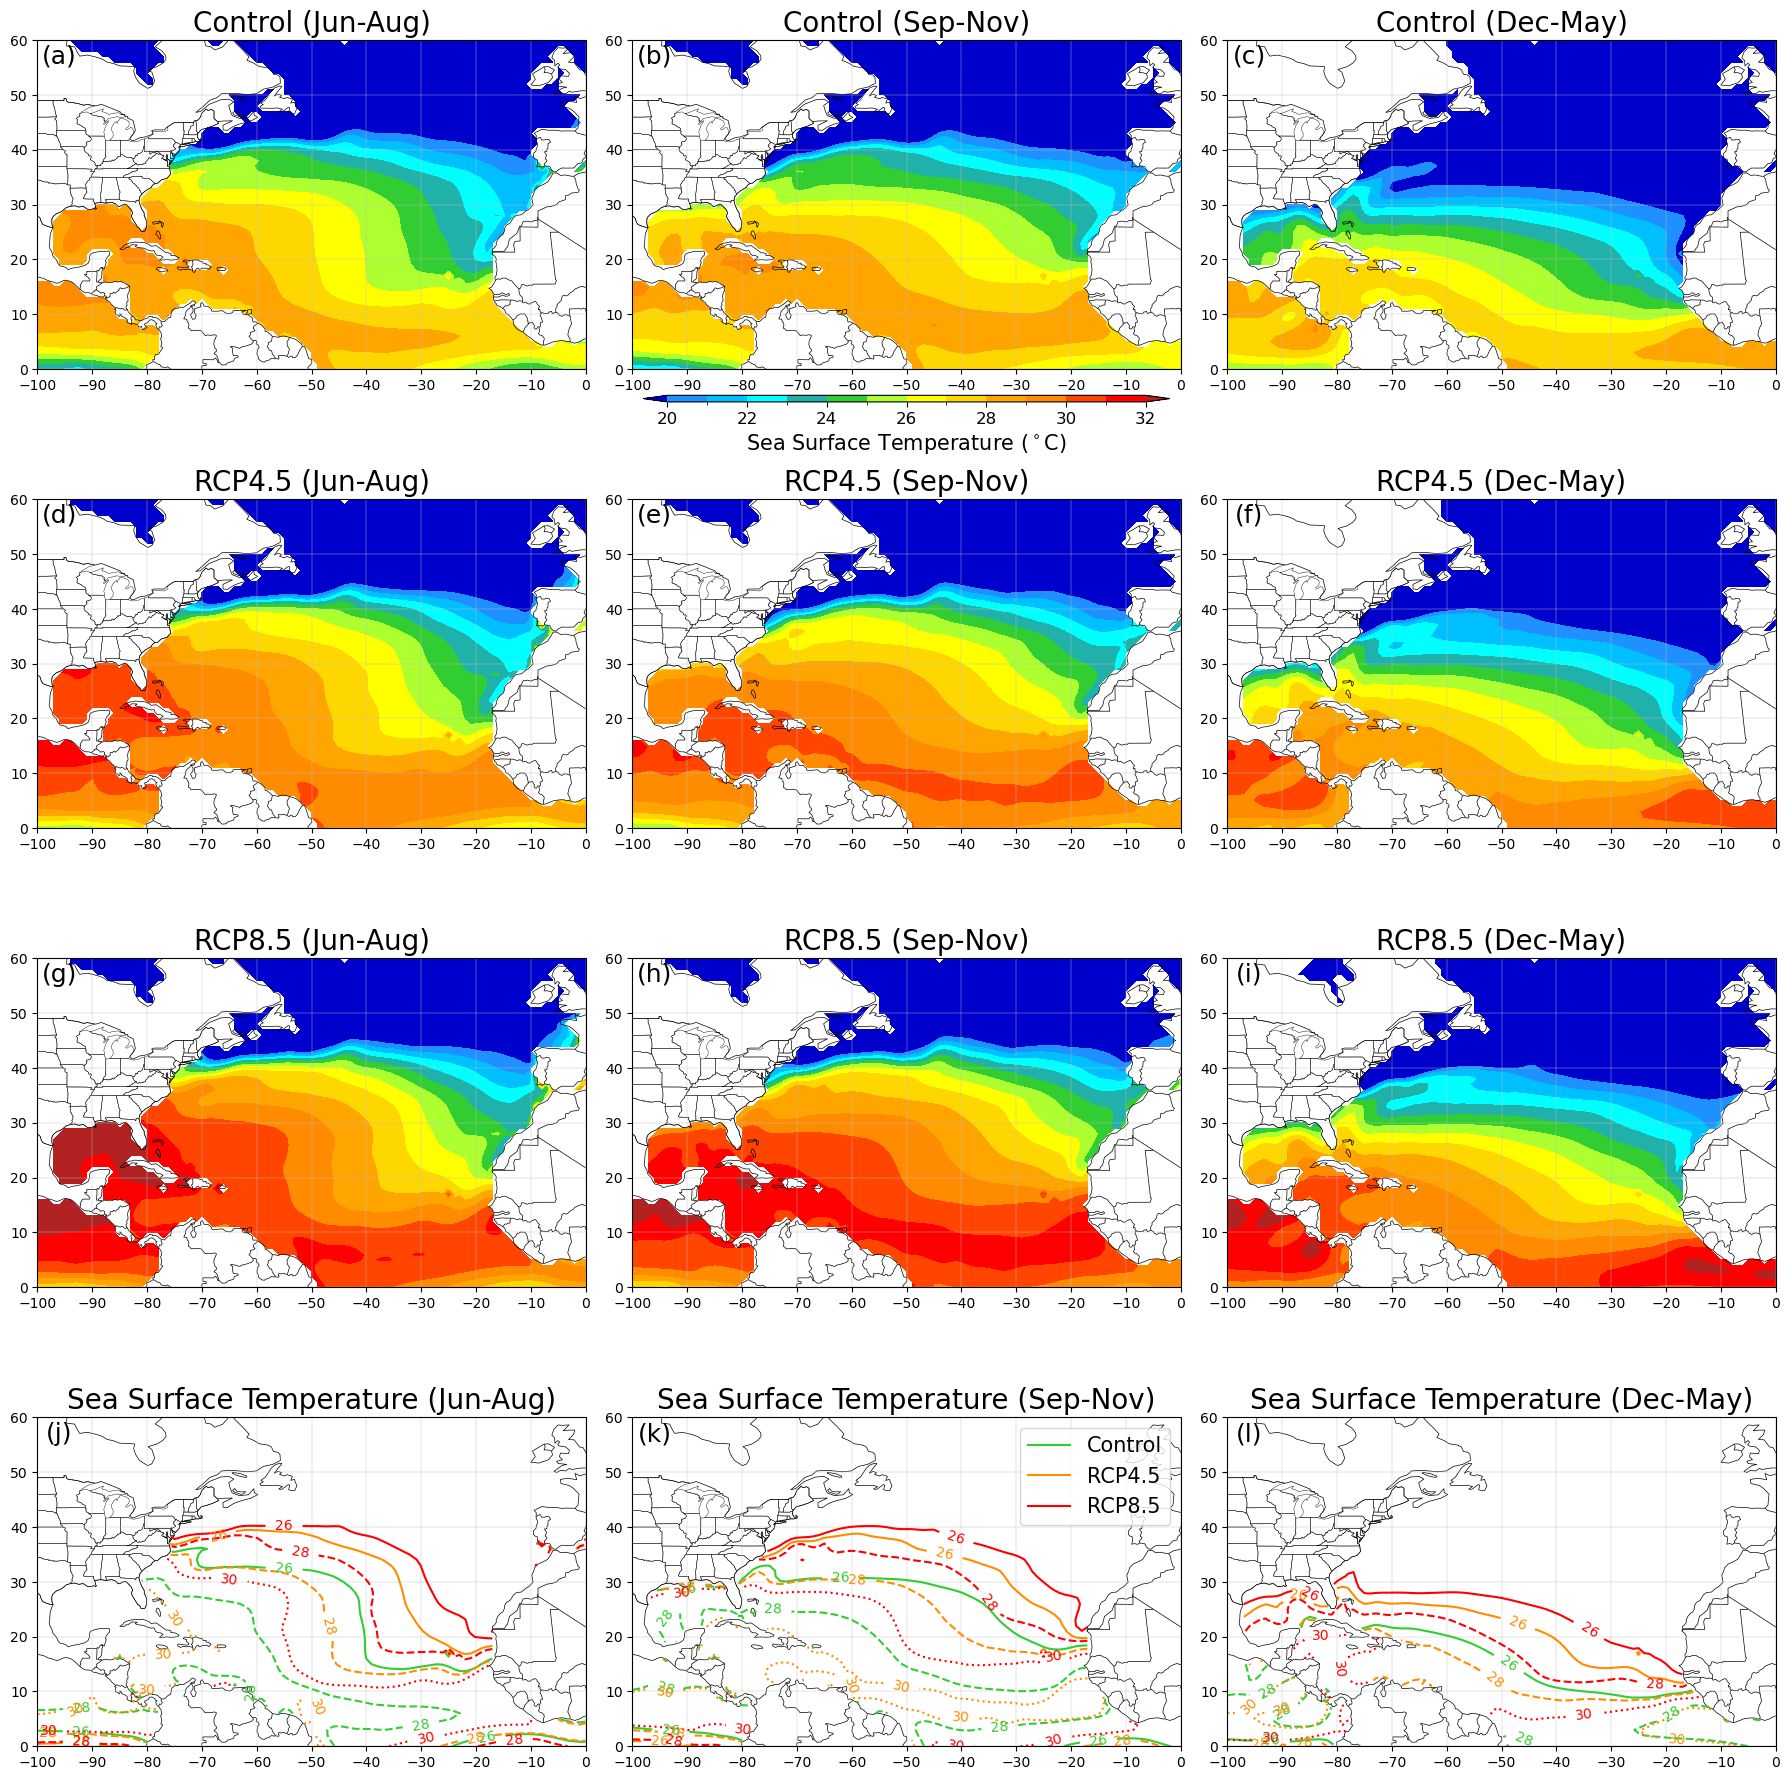

In [15]:
# Plot sea surface temperature
Months = ['Jun-Aug', 'Sep-Nov', 'Dec-May']
Var = 'TS'
Plev = 100000
Bounds, Colours = Temp_Sfc_Bounds, Temp_Sfc_Colours
Diff_Bounds, Diff_Colours = Temp_Sfc_Diff_Bounds, Temp_Sfc_Diff_Colours
Line_Bounds = Temp_Sfc_Lines_Bounds
Label, Label_Unit = 'Sea Surface Temperature', '($^\circ$C)'
Diff_Plot = False
Ocean_Only = True
Savefig = True
Figname = 'SST.png'
Variable_Contour_Plot(Control_DS_Dict, RCP45_DS_Dict, RCP85_DS_Dict, Months, Var, Plev, \
Bounds, Colours, Diff_Bounds, Diff_Colours, Line_Bounds, Label, Label_Unit, Diff_Plot, Ocean_Only, Savefig, Figname)

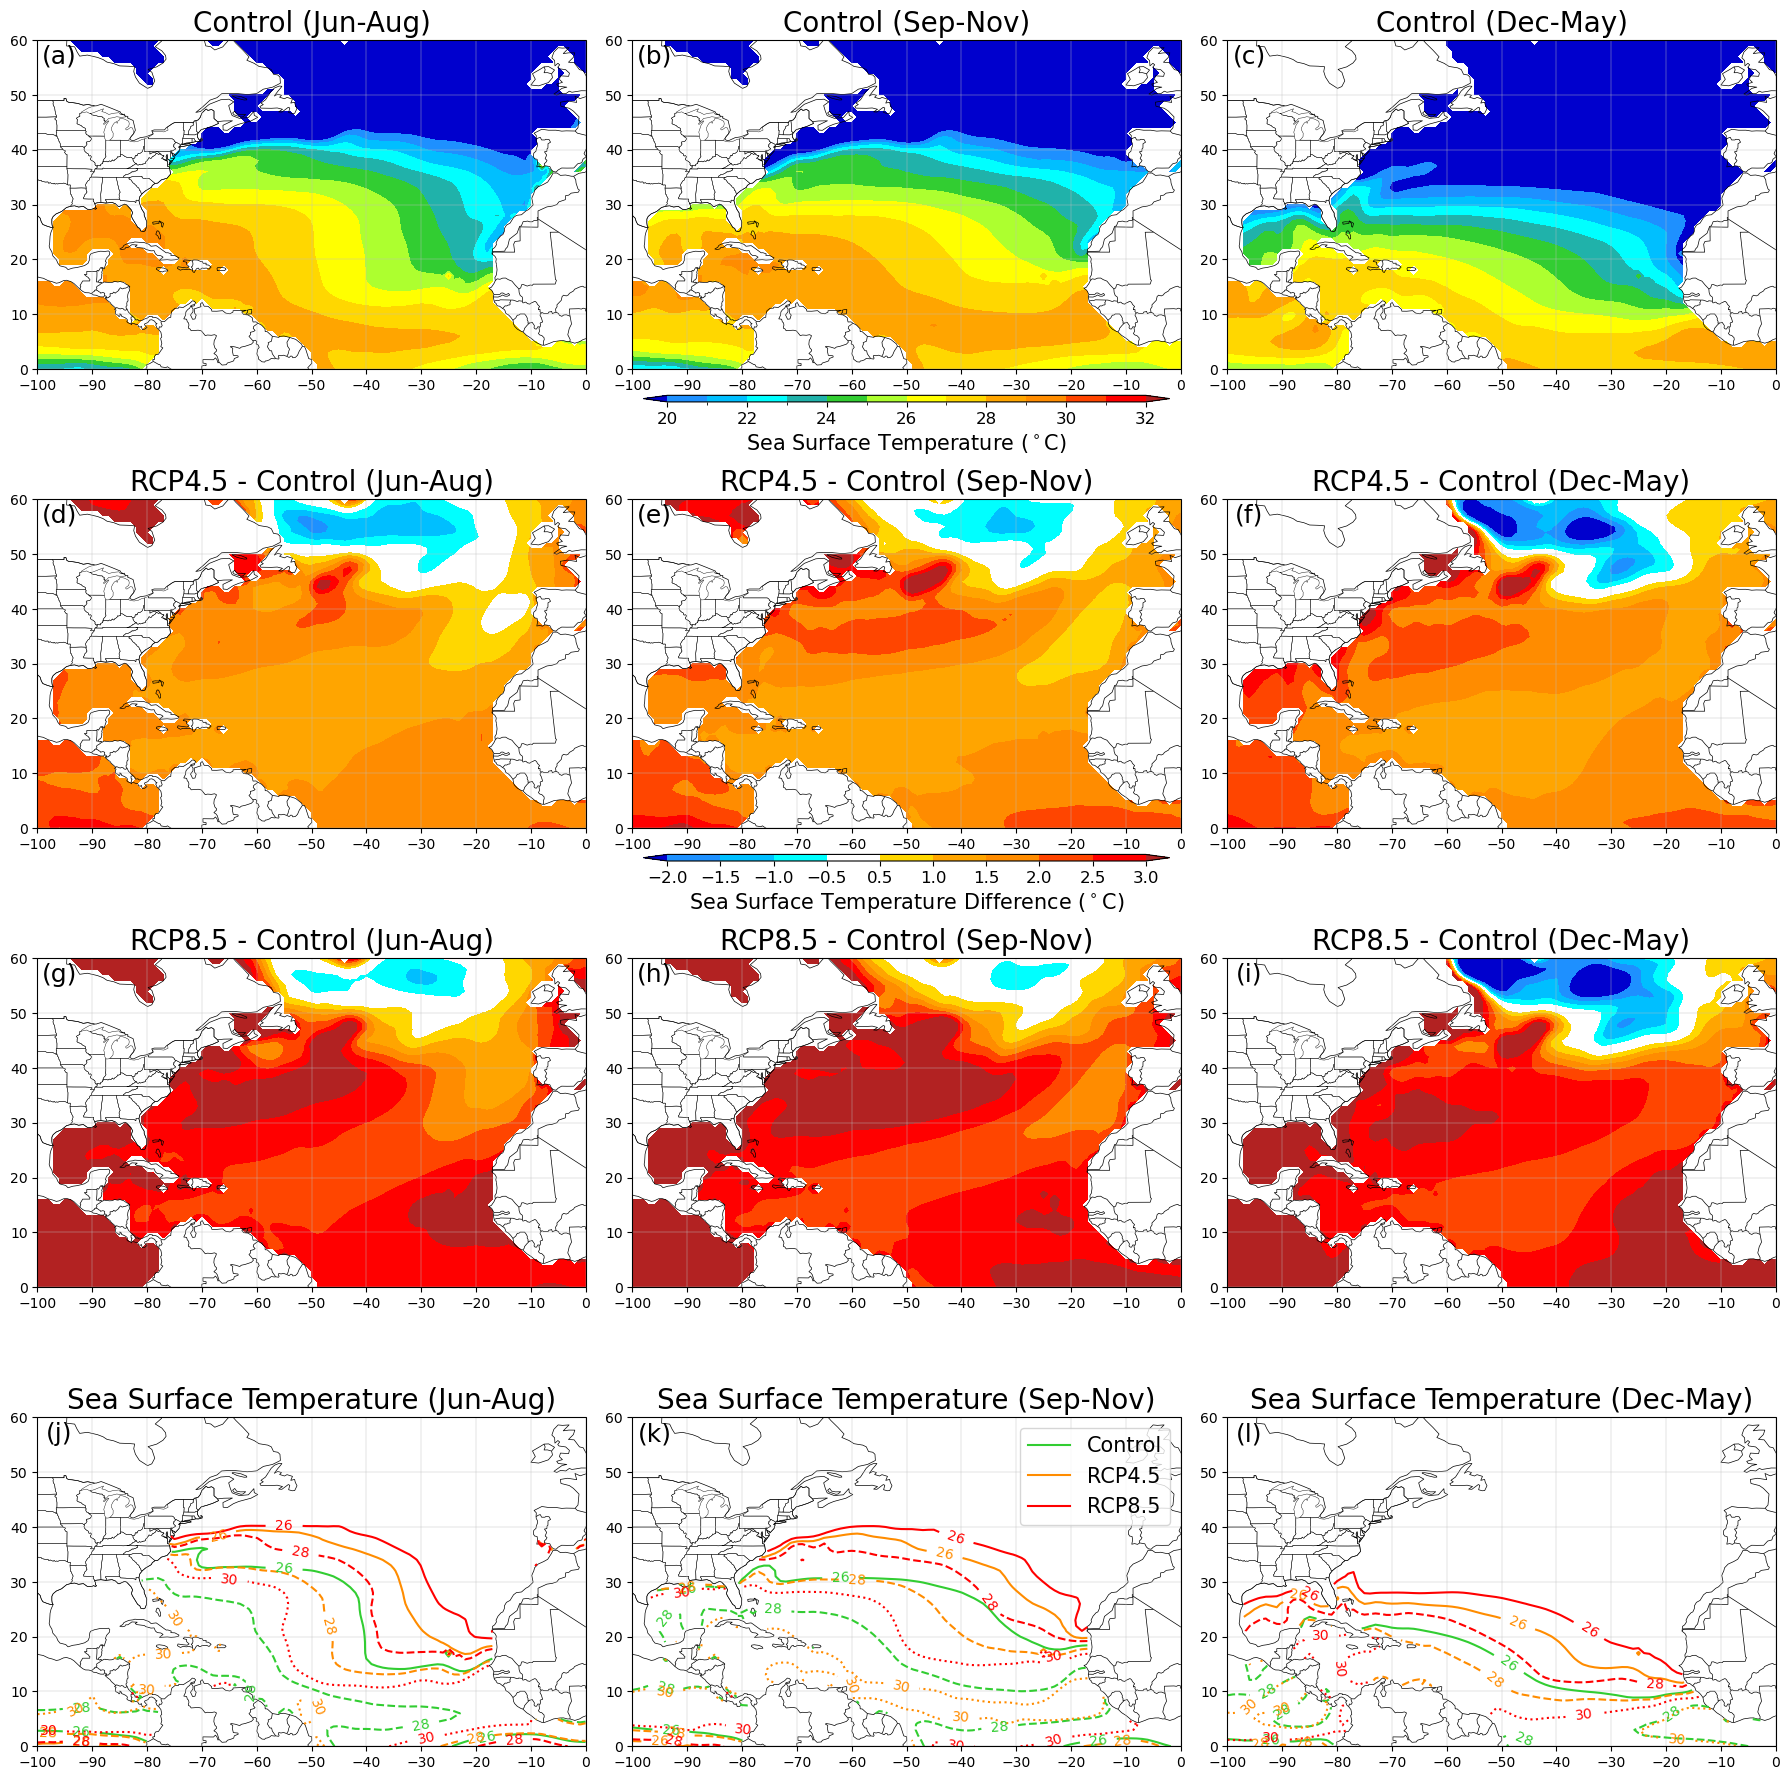

In [16]:
# Plot sea surface temperature difference
Months = ['Jun-Aug', 'Sep-Nov', 'Dec-May']
Var = 'TS'
Plev = 100000
Bounds, Colours = Temp_Sfc_Bounds, Temp_Sfc_Colours
Diff_Bounds, Diff_Colours = Temp_Sfc_Diff_Bounds, Temp_Sfc_Diff_Colours
Line_Bounds = Temp_Sfc_Lines_Bounds
Label, Label_Unit = 'Sea Surface Temperature', '($^\circ$C)'
Diff_Plot = True
Ocean_Only = True
Savefig = True
Figname = 'SST_Diff.png'
Variable_Contour_Plot(Control_DS_Dict, RCP45_DS_Dict, RCP85_DS_Dict, Months, Var, Plev, \
Bounds, Colours, Diff_Bounds, Diff_Colours, Line_Bounds, Label, Label_Unit, Diff_Plot, Ocean_Only, Savefig, Figname)

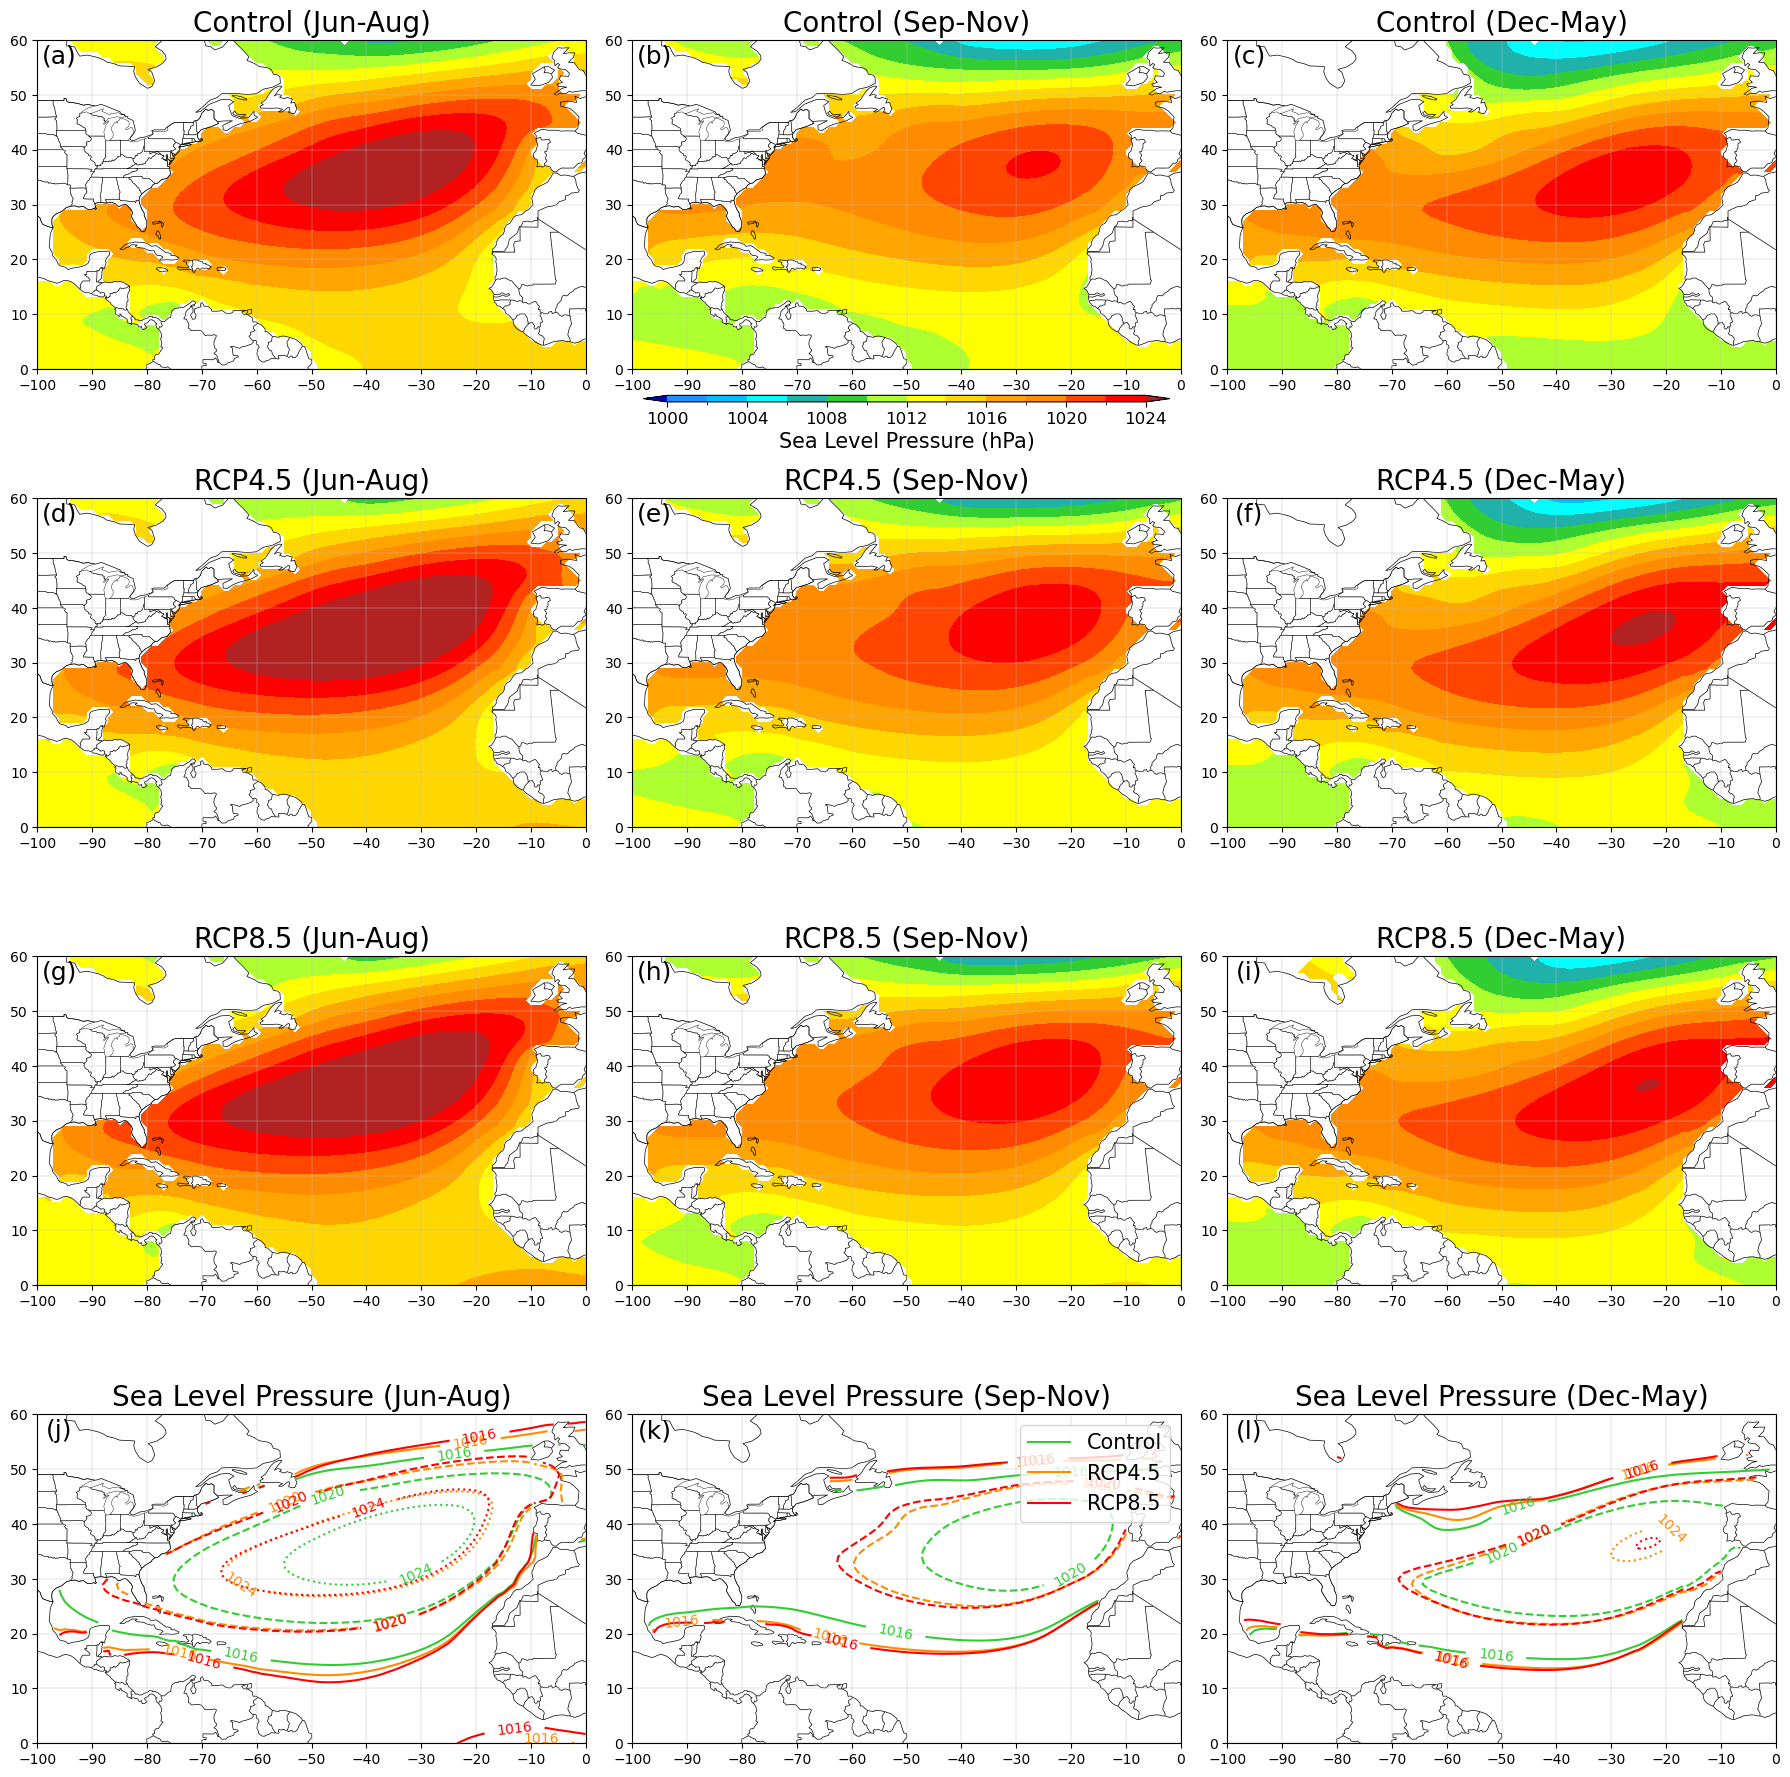

In [17]:
# Plot sea level pressure
Months = ['Jun-Aug', 'Sep-Nov', 'Dec-May']
Var = 'PSL'
Plev = 100000
Bounds, Colours = SLP_Bounds, SLP_Colours
Diff_Bounds, Diff_Colours = SLP_Diff_Bounds, SLP_Diff_Colours
Line_Bounds = SLP_Lines_Bounds
Label, Label_Unit = 'Sea Level Pressure', '(hPa)'
Diff_Plot = False
Ocean_Only = True
Savefig = True
Figname = 'SLP.png'
Variable_Contour_Plot(Control_DS_Dict, RCP45_DS_Dict, RCP85_DS_Dict, Months, Var, Plev, \
Bounds, Colours, Diff_Bounds, Diff_Colours, Line_Bounds, Label, Label_Unit, Diff_Plot, Ocean_Only, Savefig, Figname)

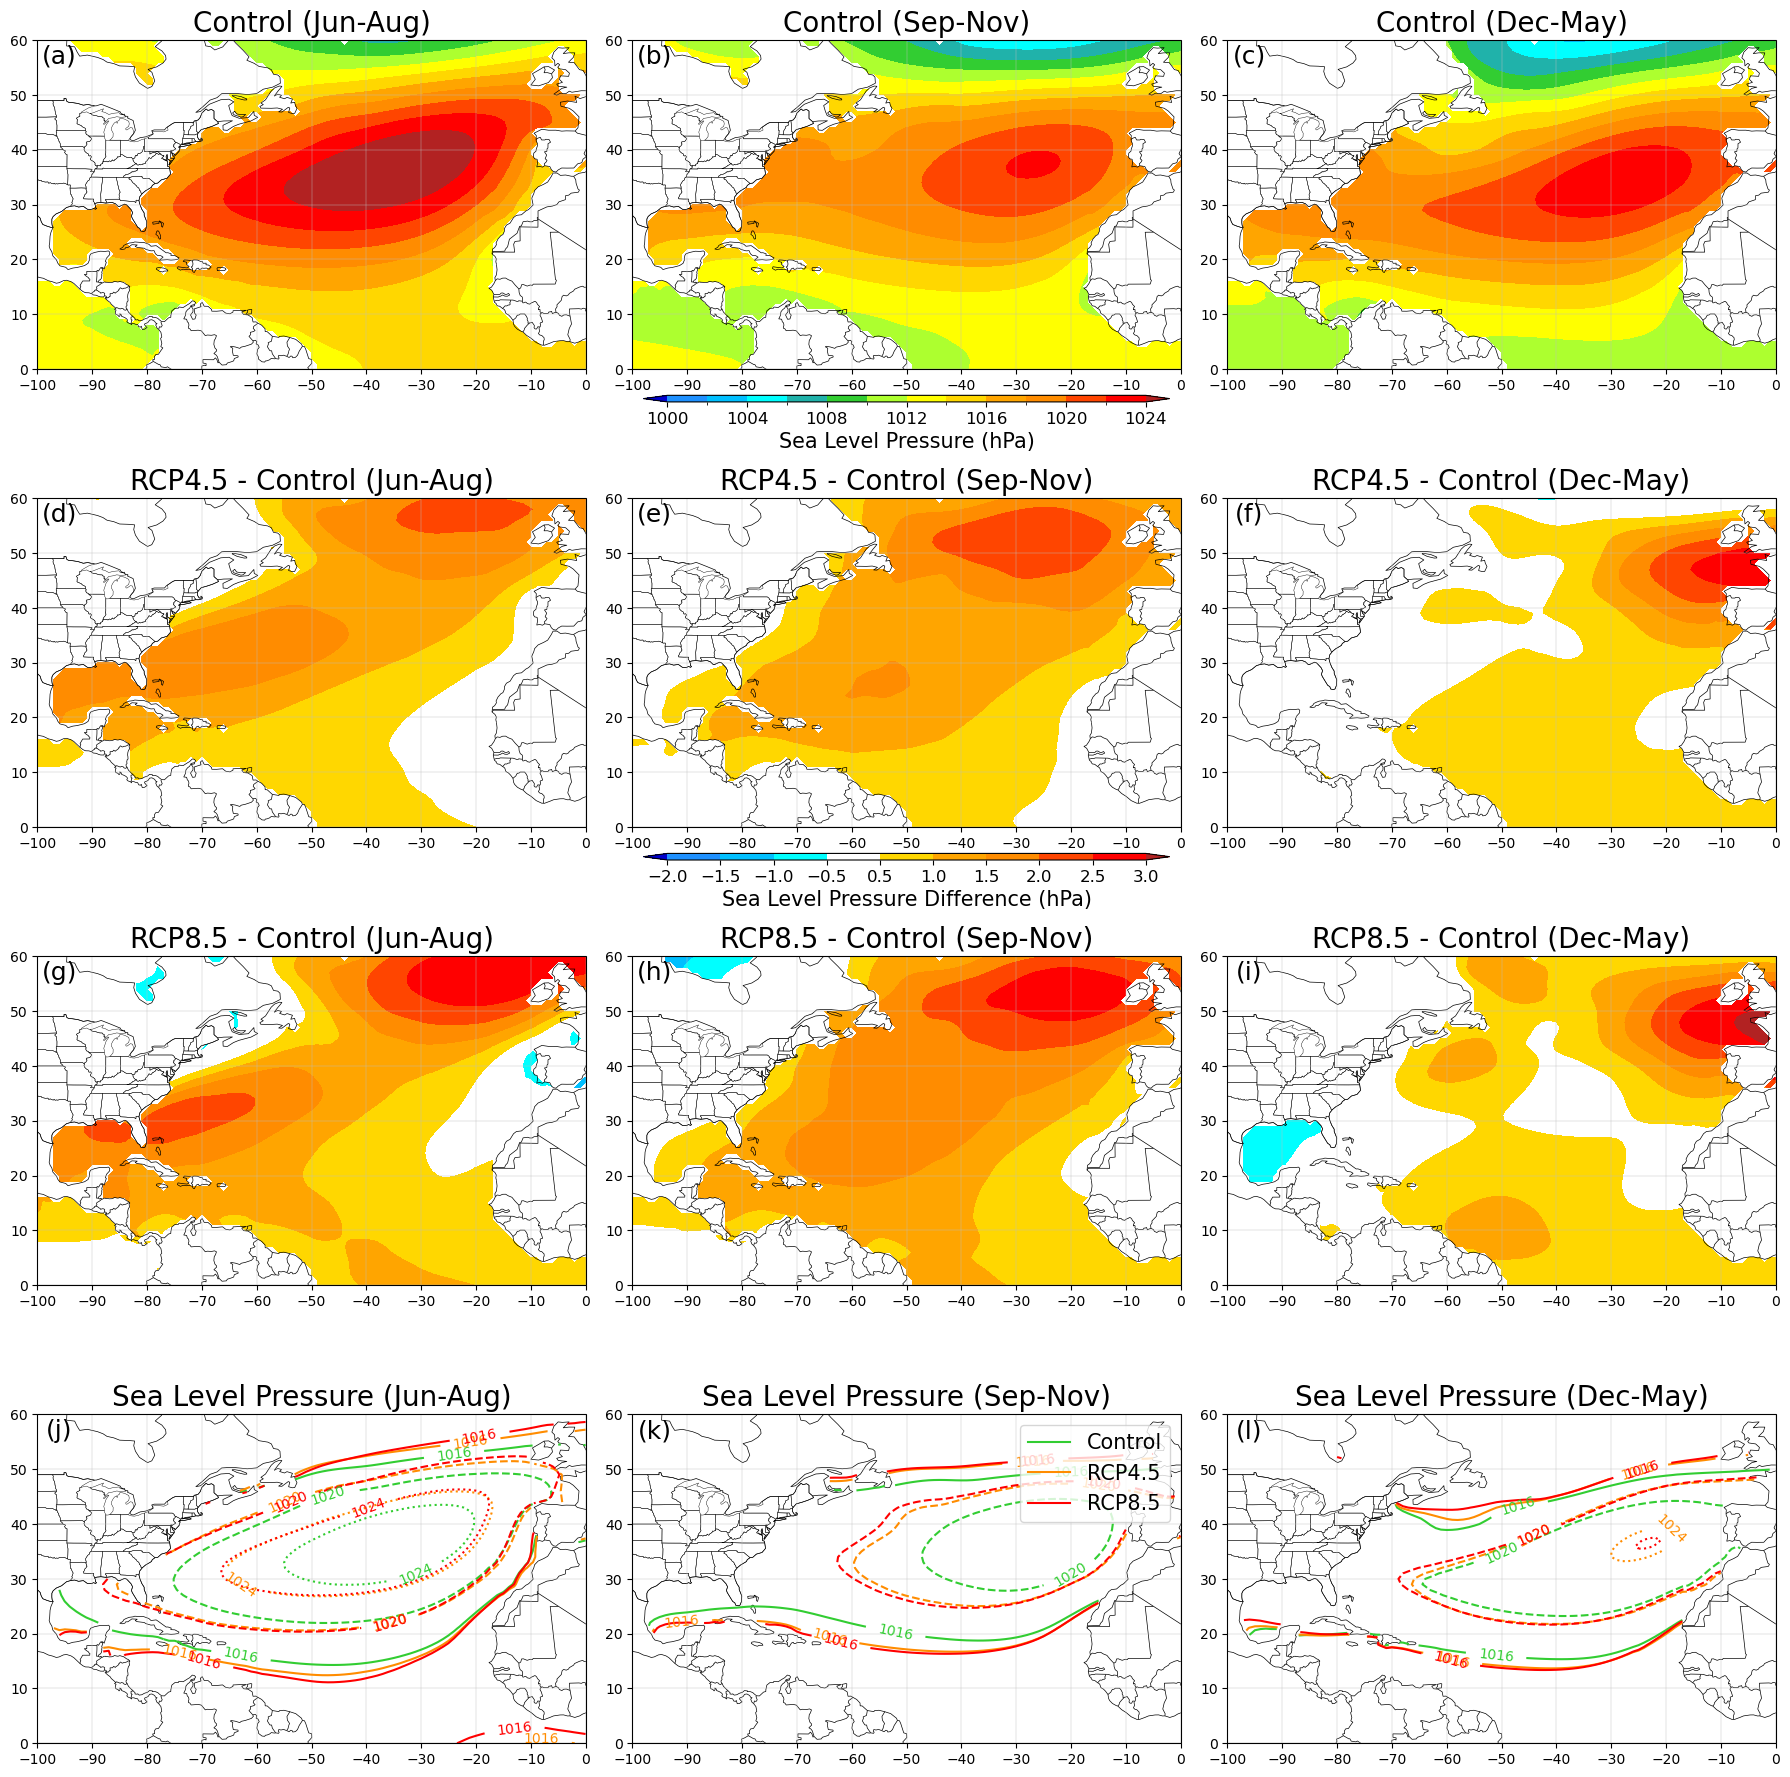

In [18]:
# Plot sea level pressure difference
Months = ['Jun-Aug', 'Sep-Nov', 'Dec-May']
Var = 'PSL'
Plev = 100000
Bounds, Colours = SLP_Bounds, SLP_Colours
Diff_Bounds, Diff_Colours = SLP_Diff_Bounds, SLP_Diff_Colours
Line_Bounds = SLP_Lines_Bounds
Label, Label_Unit = 'Sea Level Pressure', '(hPa)'
Diff_Plot = True
Ocean_Only = True
Savefig = True
Figname = 'SLP_Diff.png'
Variable_Contour_Plot(Control_DS_Dict, RCP45_DS_Dict, RCP85_DS_Dict, Months, Var, Plev, \
Bounds, Colours, Diff_Bounds, Diff_Colours, Line_Bounds, Label, Label_Unit, Diff_Plot, Ocean_Only, Savefig, Figname)